<a href="https://colab.research.google.com/github/fai1205/UCI_Heart_Disease_SprintUP_Project/blob/main/UCI_heart_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **UCI Heart Disease**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('heart_disease_uci.csv')


## 1. Data Cleaning

In [ ]:
count = df.isnull().sum()
# replace null values in numerical columns with the mean and null values in categorical columns with the mode
for col in df.columns:
    if df[col].dtype == 'float64' or df[col].dtype == 'int64':
        df[col] = df[col].fillna(df[col].mean())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])


In [ ]:
# one hot encoding for categorical columns
categorical_cols = ['cp', 'restecg', 'slope', 'thal', 'sex', 'dataset']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# standard scaling for numerical columns
numeric_cols = df_encoded.select_dtypes(include=['float64', 'int64']).columns.drop('num')
scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

### 1.1  Exploratory Data Analysis (EDA)

In [ ]:
# Histograms
df_encoded.hist(bins=20, figsize=(14, 10))
plt.suptitle("Feature Histograms")
plt.show()


In [ ]:
# heat map
plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
# box plots
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df_encoded[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## 2. Dimensionality Reduction - PCA

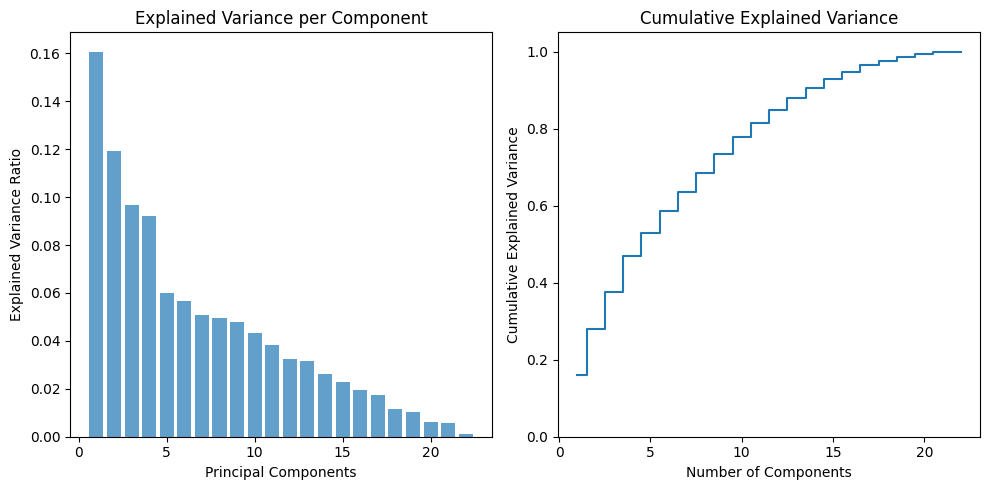

In [16]:
from sklearn.decomposition import PCA

X = df_encoded.drop(columns=['num'])

# 1. Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 3. Explained variance ratio (to determine optimal number of components)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot explained variance ratio and cumulative variance
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.7, align='center')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.title('Explained Variance per Component')

plt.subplot(1,2,2)
plt.step(range(1, len(cumulative_variance)+1), cumulative_variance, where='mid')
plt.ylabel('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.title('Cumulative Explained Variance')
plt.ylim(0,1.05)

plt.tight_layout()
plt.show()


## 3. Feature Selection

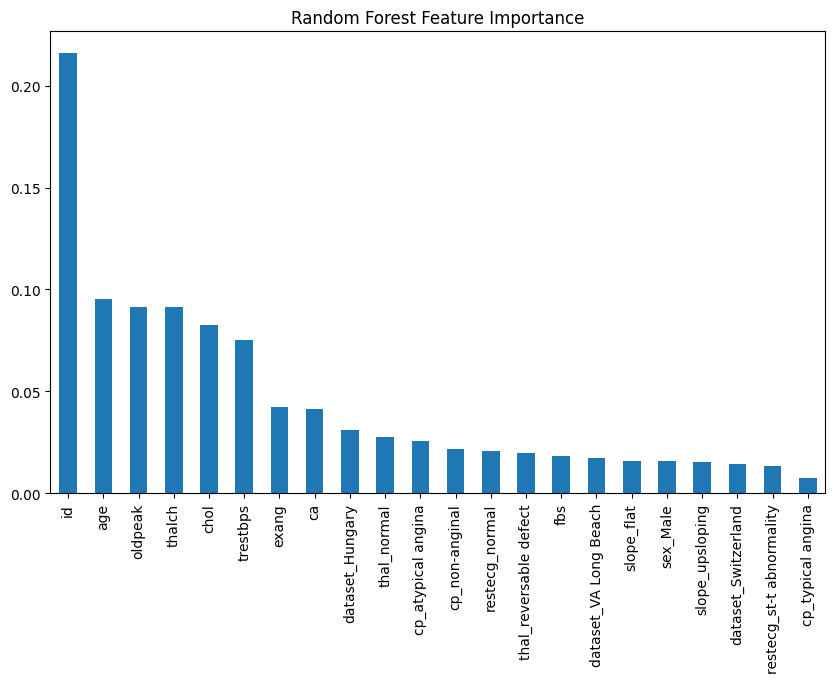

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
y = df['num']
rf.fit(X, y)

# Get feature importances and sort
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Plot feature importance
plt.figure(figsize=(10,6))
importances.plot(kind='bar')
plt.title('Random Forest Feature Importance')
plt.show()


In [19]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
rfe = RFE(model, n_features_to_select=10)  # choose number of features
fit = rfe.fit(X, y)

selected_features = X.columns[fit.support_]
print("Selected features by RFE:", list(selected_features))

Selected features by RFE: ['id', 'oldpeak', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'thal_normal', 'sex_Male', 'dataset_Hungary', 'dataset_Switzerland', 'dataset_VA Long Beach']


In [22]:
from sklearn.feature_selection import SelectKBest, chi2

categorical_features = [col for col in X.columns if set(X[col].unique()).issubset({0,1})]

X_cat = X[categorical_features]

chi2_selector = SelectKBest(chi2, k=10)
X_kbest = chi2_selector.fit_transform(X_cat, y)

selected_features_chi2 = X_cat.columns[chi2_selector.get_support()]
print("Selected features by Chi-Square Test:", list(selected_features_chi2))



Selected features by Chi-Square Test: ['exang', 'cp_atypical angina', 'cp_non-anginal', 'slope_upsloping', 'thal_normal', 'thal_reversable defect', 'sex_Male', 'dataset_Hungary', 'dataset_Switzerland', 'dataset_VA Long Beach']


In [23]:
X_reduced = X[selected_features]

## 4. Supervised Learning - Classification Models

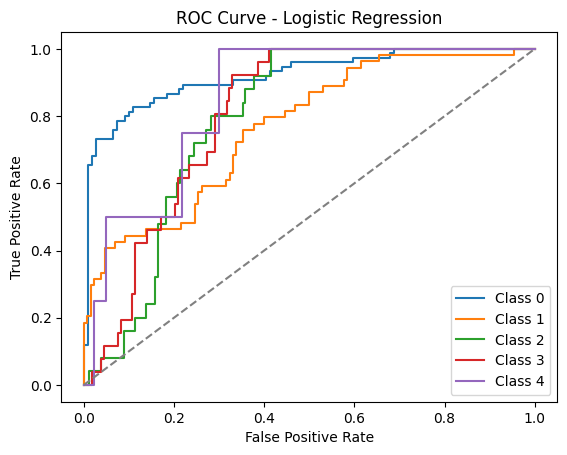

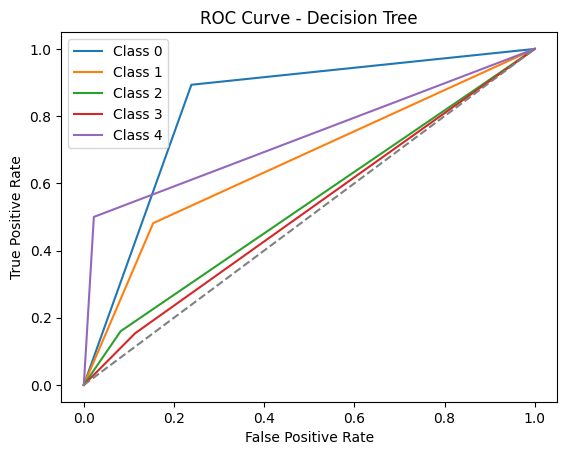

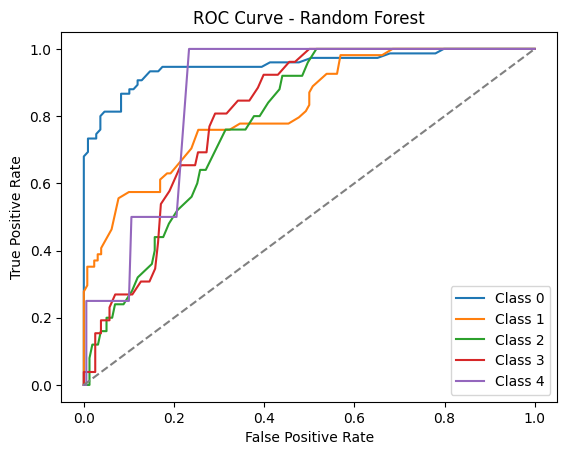

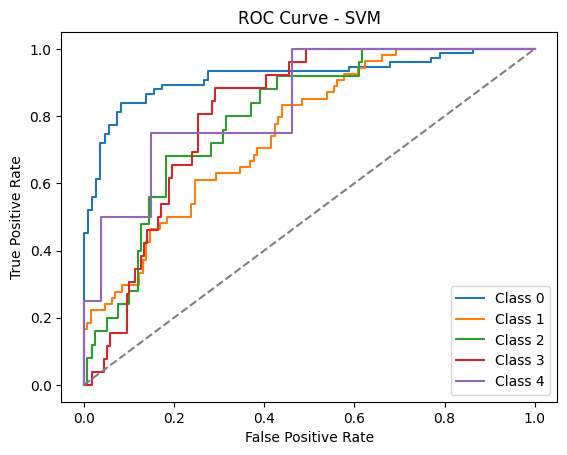

Model: Logistic Regression
  Accuracy: 0.5543
  Precision: 0.4877
  Recall: 0.5543
  F1-Score: 0.5119
  AUC: 0.8280

Model: Decision Tree
  Accuracy: 0.5598
  Precision: 0.5244
  Recall: 0.5598
  F1-Score: 0.5359
  AUC: 0.6578

Model: Random Forest
  Accuracy: 0.6196
  Precision: 0.5709
  Recall: 0.6196
  F1-Score: 0.5862
  AUC: 0.8452

Model: SVM
  Accuracy: 0.5598
  Precision: 0.4914
  Recall: 0.5598
  F1-Score: 0.5094
  AUC: 0.8232



In [28]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Calculate multiclass AUC with proper multi_class parameter
    if y_proba is not None:
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
    else:
        auc = None

    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "AUC": auc
    }

    # Plot ROC curve only if probability is available (binary/multiclass handled)
    if y_proba is not None:
        # For multiclass, compute ROC for each class
        plt.figure()
        for i in range(y_proba.shape[1]):
            fpr, tpr, _ = roc_curve(y_test == i, y_proba[:, i])
            plt.plot(fpr, tpr, label=f"Class {i}")
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.title(f'ROC Curve - {name}')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend()
        plt.show()

# Print performance metrics
for model_name, metrics in results.items():
    print(f"Model: {model_name}")
    for metric_name, value in metrics.items():
        if value is not None:
            print(f"  {metric_name}: {value:.4f}")
    print()


## 5. Unsupervised Learning -- Clustering

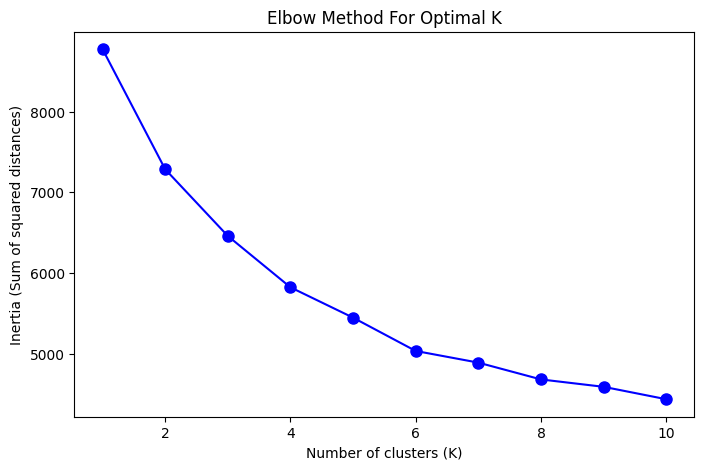

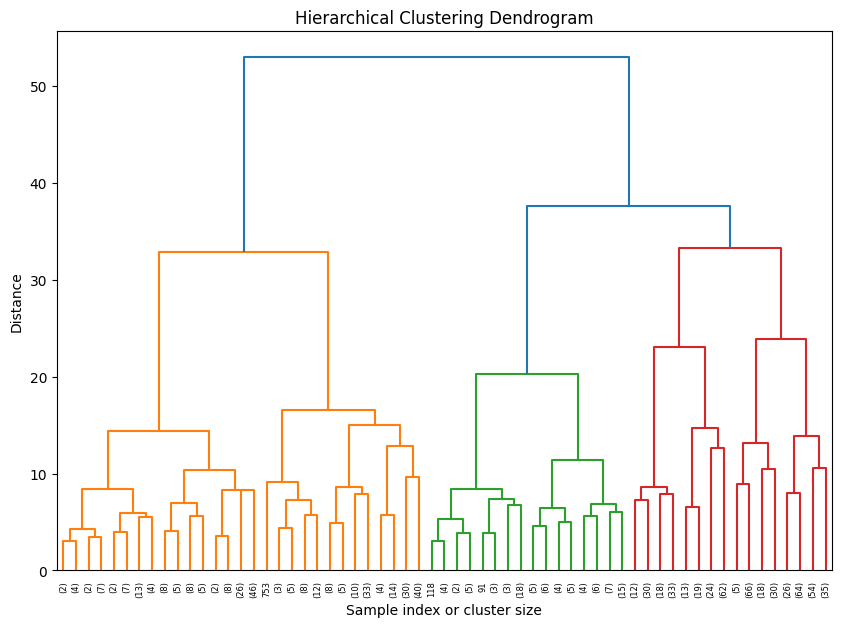

Adjusted Rand Index for K-Means: 0.2145
Adjusted Rand Index for Hierarchical Clustering: 0.1863


In [29]:
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import adjusted_rand_score

# Assume X contains your feature matrix (scaled/encoded), and y is the actual labels

# 1. K-Means Clustering with Elbow Method to find optimal K
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, 'bo-', markersize=8)
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia (Sum of squared distances)')
plt.title('Elbow Method For Optimal K')
plt.show()

# Choose optimal K (e.g., elbow point) - suppose K=3
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

# 2. Hierarchical Clustering with dendrogram
linked = linkage(X, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(linked, truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index or cluster size')
plt.ylabel('Distance')
plt.show()

# Cut dendrogram to form flat clusters - choose number of clusters, e.g., 3
hier_labels = fcluster(linked, t=3, criterion='maxclust')

# 3. Compare clusters with actual disease labels using Adjusted Rand Index
ari_kmeans = adjusted_rand_score(y, kmeans_labels)
ari_hier = adjusted_rand_score(y, hier_labels)

print(f"Adjusted Rand Index for K-Means: {ari_kmeans:.4f}")
print(f"Adjusted Rand Index for Hierarchical Clustering: {ari_hier:.4f}")


## 6. Hyperparameter Tuning

In [31]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import classification_report

rf = RandomForestClassifier(random_state=42)

# Define hyperparameters grid for GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, n_jobs=-1, scoring='accuracy')

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

print(f"Best hyperparameters (GridSearchCV): {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Evaluate on test set
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)
print("Classification report on test set:")
print(classification_report(y_test, y_pred))

# Alternatively, RandomizedSearchCV for larger hyperparameter space
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': [None] + list(np.arange(5, 30, 5)),
    'min_samples_split': randint(2, 11),
    'min_samples_leaf': randint(1, 5),
    'bootstrap': [True, False]
}

random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist,
                                   n_iter=20, cv=5, n_jobs=-1, scoring='accuracy', random_state=42)

random_search.fit(X_train, y_train)
print(f"Best hyperparameters (RandomizedSearchCV): {random_search.best_params_}")
print(f"Best cross-validation accuracy: {random_search.best_score_:.4f}")

# Evaluate randomized search best model on test set
best_rf_random = random_search.best_estimator_
y_pred_random = best_rf_random.predict(X_test)
print("Classification report from RandomizedSearchCV best model:")
print(classification_report(y_test, y_pred_random))

Best hyperparameters (GridSearchCV): {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 50}
Best cross-validation accuracy: 0.6576
Classification report on test set:
              precision    recall  f1-score   support

           0       0.67      0.96      0.79        75
           1       0.58      0.56      0.57        54
           2       0.27      0.12      0.17        25
           3       0.23      0.12      0.15        26
           4       0.00      0.00      0.00         4

    accuracy                           0.59       184
   macro avg       0.35      0.35      0.33       184
weighted avg       0.51      0.59      0.53       184



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Best hyperparameters (RandomizedSearchCV): {'bootstrap': False, 'max_depth': np.int64(20), 'min_samples_leaf': 4, 'min_samples_split': 3, 'n_estimators': 160}
Best cross-validation accuracy: 0.6494
Classification report from RandomizedSearchCV best model:
              precision    recall  f1-score   support

           0       0.69      0.93      0.80        75
           1       0.61      0.57      0.59        54
           2       0.31      0.20      0.24        25
           3       0.31      0.19      0.24        26
           4       0.00      0.00      0.00         4

    accuracy                           0.60       184
   macro avg       0.39      0.38      0.37       184
weighted avg       0.55      0.60      0.56       184



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 7. Exporting

In [33]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Fit pipeline on training data
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', RandomForestClassifier(random_state=42))])

In [34]:
import joblib

joblib.dump(pipeline, 'heart_disease_pipeline.pkl')
print("Model pipeline saved successfully.")

Model pipeline saved successfully.


In [35]:
loaded_pipeline = joblib.load('heart_disease_pipeline.pkl')

y_pred = loaded_pipeline.predict(X_test)